In [12]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load the diabetes dataset
diabetes = load_diabetes()

# Convert to pandas DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# Show first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [13]:
# Step 3: Basic information about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (442, 11)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Basic statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905

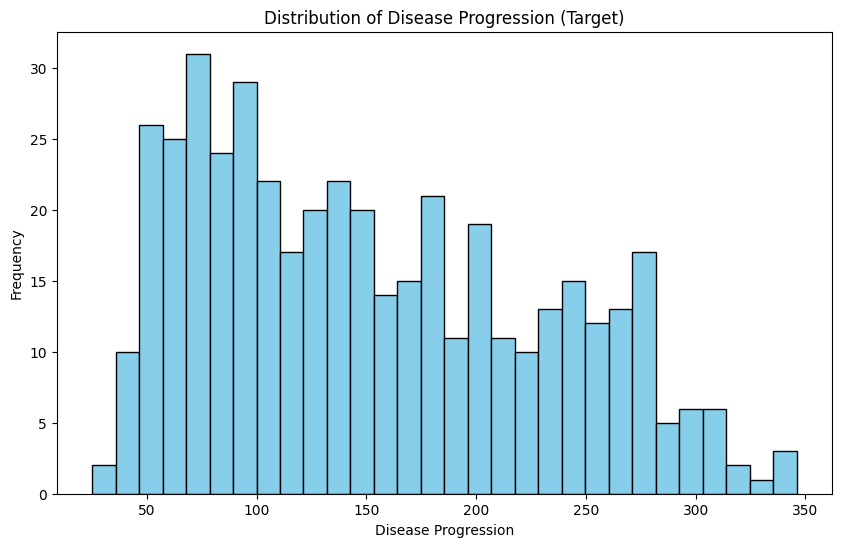

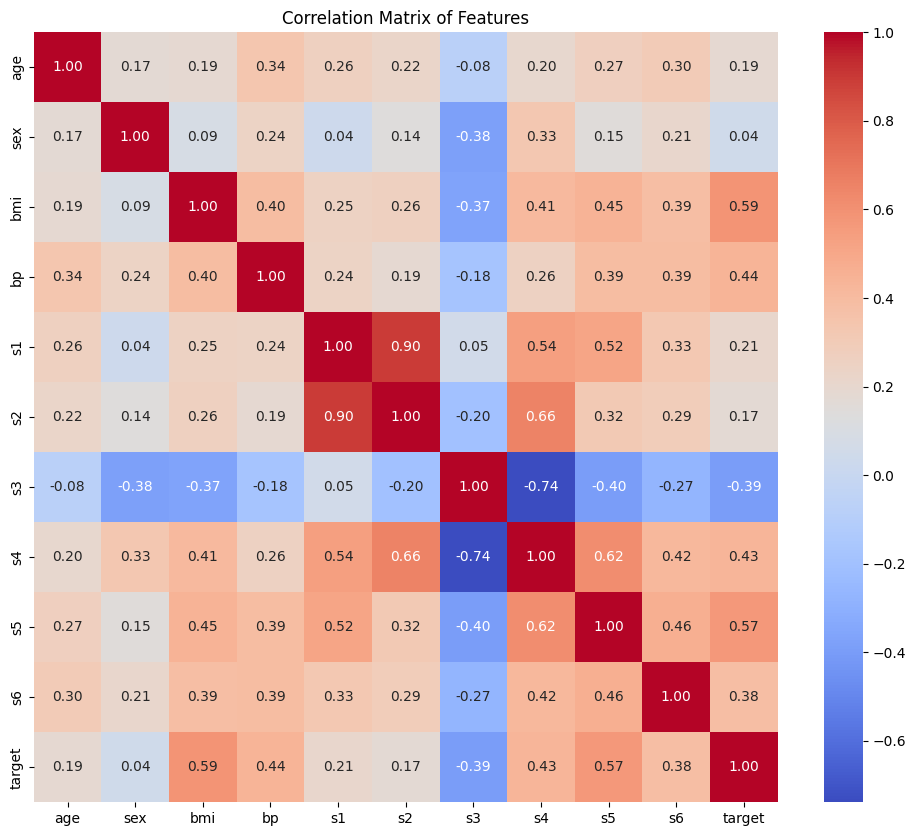

In [14]:
# Step 4: Visualize the target distribution
plt.figure(figsize=(10, 6))
plt.hist(df['target'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Disease Progression (Target)')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [15]:
# Step 5: Prepare data for modeling
X = df.drop('target', axis=1)  # Features
y = df['target']  # Target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (353, 10)
Testing set size: (89, 10)


In [16]:
# Step 6: Train Lasso Regression with different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10]

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"Alpha = {alpha}: R² Score = {r2:.4f}, Non-zero coefficients = {sum(lasso.coef_ != 0)}")

Alpha = 0.001: R² Score = 0.4533, Non-zero coefficients = 10
Alpha = 0.01: R² Score = 0.4567, Non-zero coefficients = 10
Alpha = 0.1: R² Score = 0.4719, Non-zero coefficients = 7
Alpha = 1: R² Score = 0.3576, Non-zero coefficients = 3
Alpha = 10: R² Score = -0.0120, Non-zero coefficients = 0


In [17]:
# Step 7: Choose best alpha (let's use 0.1)
best_alpha = 0.1
lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_best.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)

print(f"Best Alpha: {best_alpha}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Show which features were selected
print("\nFeature Coefficients (Lasso):")
for feature, coef in zip(X.columns, lasso_best.coef_):
    print(f"{feature}: {coef:.4f}")

Best Alpha: 0.1
Mean Squared Error: 2798.19
R² Score: 0.4719

Feature Coefficients (Lasso):
age: 0.0000
sex: -152.6648
bmi: 552.6978
bp: 303.3652
s1: -81.3650
s2: -0.0000
s3: -229.2558
s4: 0.0000
s5: 447.9195
s6: 29.6426


In [18]:
# Step 8: Compare Lasso with Linear and Ridge Regression
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=0.1),
    'Lasso Regression': Lasso(alpha=0.1)
}

print("Model Comparison:")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    n_features = sum(model.coef_ != 0) if hasattr(model, 'coef_') else 'N/A'
    print(f"{name}: R² = {r2:.4f}, Features Used = {n_features}")

Model Comparison:
--------------------------------------------------
Linear Regression: R² = 0.4526, Features Used = 10
Ridge Regression: R² = 0.4609, Features Used = 10
Lasso Regression: R² = 0.4719, Features Used = 7


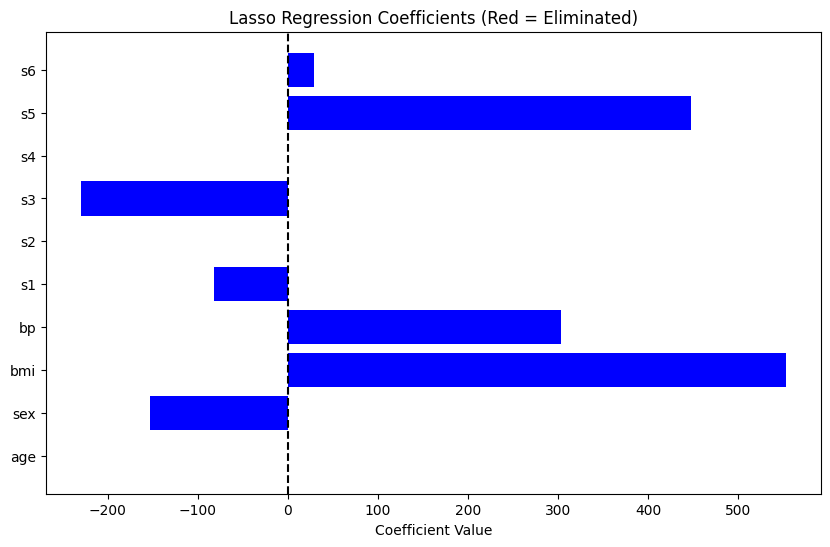

In [19]:
# Step 9: Visualize Lasso coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if coef == 0 else 'blue' for coef in lasso_best.coef_]
plt.barh(X.columns, lasso_best.coef_, color=colors)
plt.xlabel('Coefficient Value')
plt.title('Lasso Regression Coefficients (Red = Eliminated)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

In [20]:
# Step 10: Save results to a CSV file
results = pd.DataFrame({
    'Feature': X.columns,
    'Lasso_Coefficient': lasso_best.coef_
})
results.to_csv('lasso_coefficients.csv', index=False)
print("Results saved to lasso_coefficients.csv")

Results saved to lasso_coefficients.csv
